# 📋 Collaboration Report  

##▶️ การแบ่งหน้าที่และการดำเนินงานระบบเครือข่าย

รายงานฉบับนี้แสดงรายละเอียดการทำงานร่วมกันของสมาชิกในกลุ่ม  
โดยอธิบาย **สิ่งที่สมาชิกแต่ละคนได้ปฏิบัติจริงระหว่างการดำเนินงาน Lab**  
ตามโครงสร้างเครือข่าย **Router – Switch – PC**  

## **สมาชิก**
**นายพัทธดนย์ คำนัน 673380416-3 (โบร์ท)**  
**นายสิทธิโชค มุขนาค 673380428-6 (บูบู้)**  
**นายณัฐภัทร ฉ่ำตะคุ 673380583-4 (อ้น)**  
**นายสรวิศ สุคงเจริญ 673380606-8 (โอ่ง)**  
**นางสาวอมลวรรณ พิมพิชัย 673380608-4 (เนย)**  

---

### 📌 Topology Overview
- **Network:** 192.168.1.0 /24  
- **Router:** 192.168.1.1  
- **Switch (VLAN 1):** 192.168.1.2  
- **PC1:** 192.168.1.10  
- **PC2:** 192.168.1.11  

---

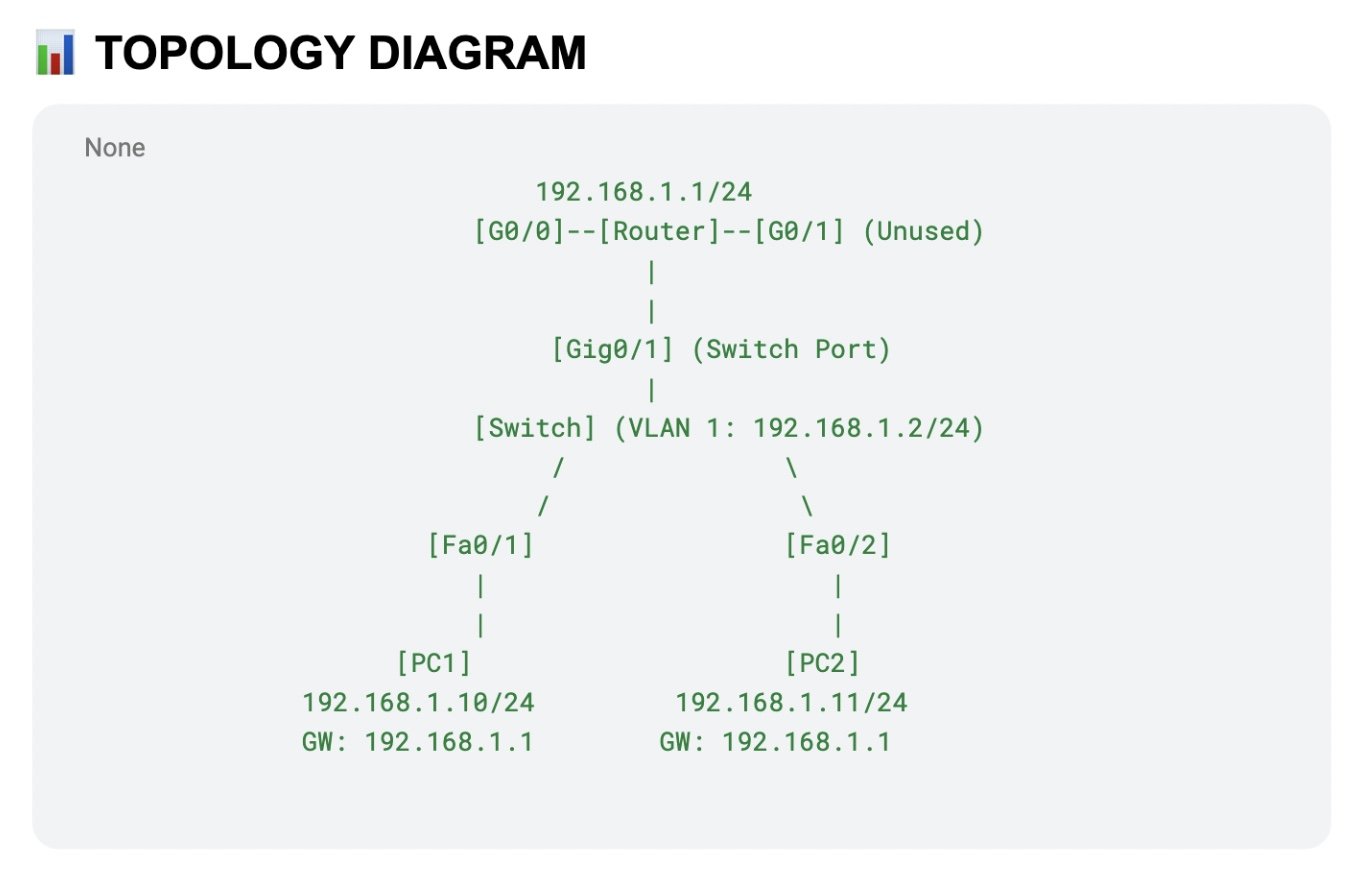

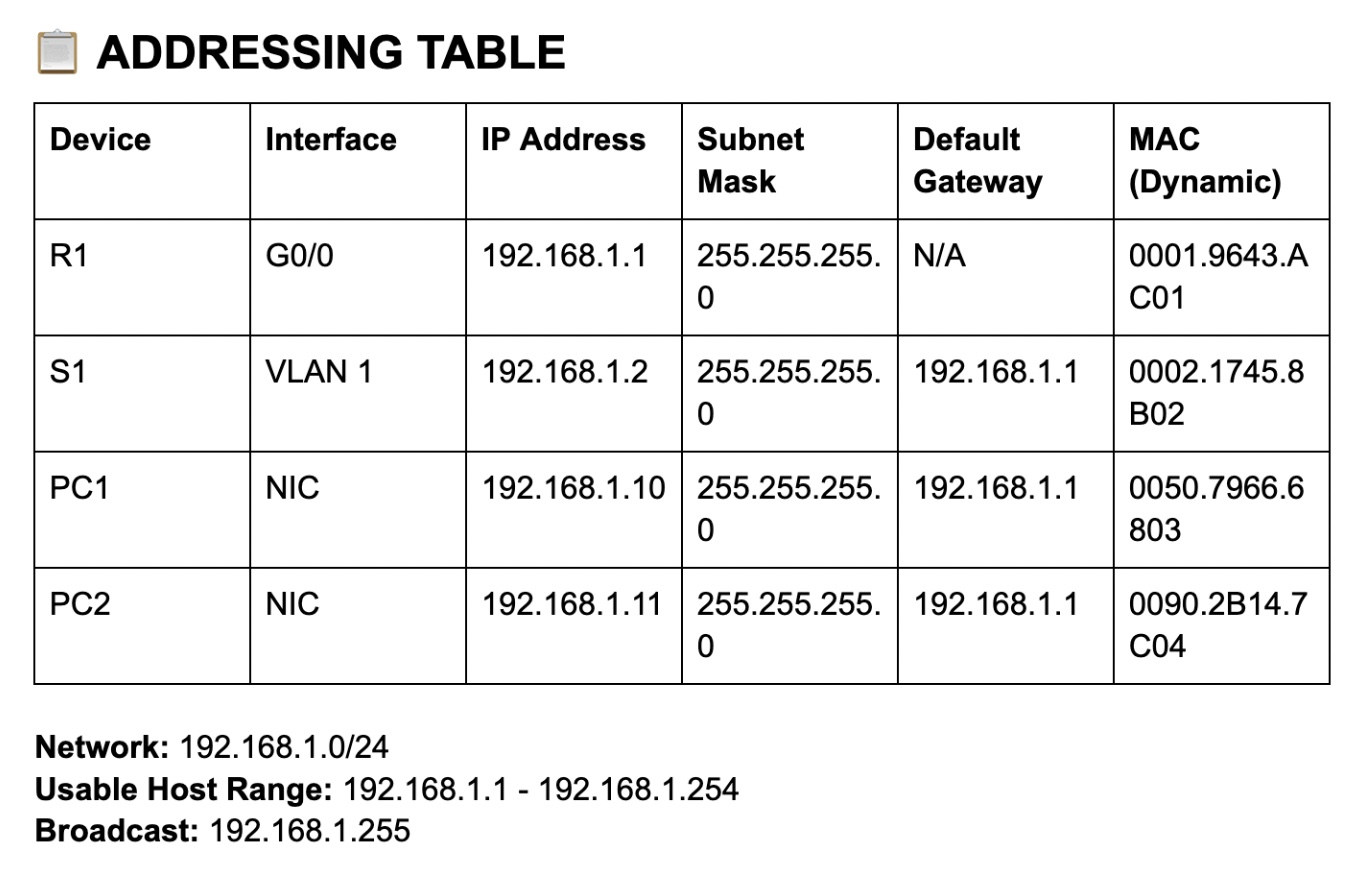

---
#👤 Part 1: การกำหนดค่าพื้นฐานและ IP Addressing (โบร์ท)

**หน้าที่: วางรากฐานระบบเครือข่ายเพื่อให้ทุกอุปกรณ์รู้จักกัน**

**ขั้นตอนการดำเนินงาน**

1. **Router Configuration (R1)**

 * เข้าสู่โหมด `Global Configuration` และเปลี่ยนชื่ออุปกรณ์ด้วยคำสั่ง `hostname R1`

 * เปิดใช้งานพอร์ต GigabitEthernet 0/0 และกำหนด IP `192.168.1.1` พร้อม Subnet Mask `255.255.255.0`

```
enable
configure terminal
hostname R1
interface GigabitEthernet0/0
 ip address 192.168.1.1 255.255.255.0
 no shutdown
exit

```

2. **Switch Configuration (S1)**

 * ตั้งค่า Management IP บน `interface vlan 1` เป็น `192.168.1.2`

 * กำหนด `ip default-gateway 192.168.1.1` เพื่อให้ Switch ติดต่อสื่อสารข้ามเครือข่ายได้

```
enable
configure terminal
hostname S1
interface vlan 1
 ip address 192.168.1.2 255.255.255.0
 no shutdown
exit
ip default-gateway 192.168.1.1
```

3. **End Device Setup**
 * กำหนด Static IP ให้ **PC1** (`192.168.1.10`) และ **PC2** (`192.168.1.11`)

 * ตรวจสอบว่าทุกเครื่องชี้ Gateway ไปที่ `192.168.1.1`

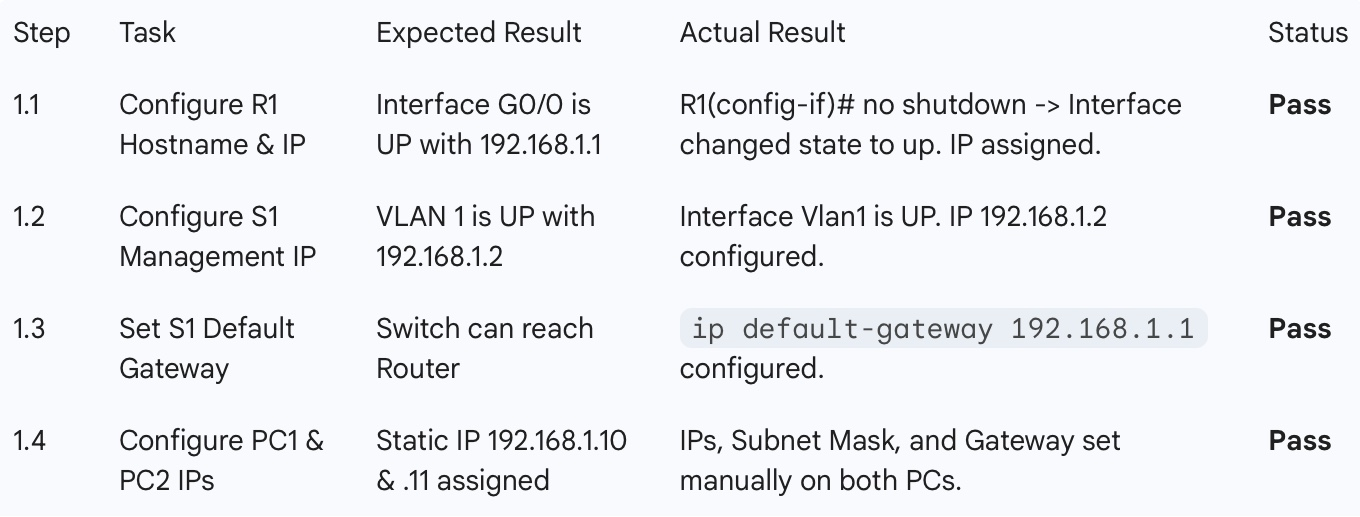

---
#👤 Part 2: การตรวจสอบสถานะและการเชื่อมต่อ (โอ่ง)

**หน้าที่: ทดสอบว่าสายสัญญาณและการตั้งค่า IP ทำงานได้จริง**

**ขั้นตอนการดำเนินงาน**

1. **Physical Link Check**

 * ตรวจสอบไฟสถานะบนพอร์ตต่างๆ (Link Lights) ว่าเป็นสีเขียวทั้งหมดหรือไม่

2. **Ping Command Test**  

 * จาก PC1 ใช้คำสั่ง `ping 192.168.1.1` เพื่อเช็ค Gateway

 * จาก PC1 ใช้คำสั่ง `ping 192.168.1.11` เพื่อเช็คความร่วมมือกับ PC2

```
[รันบน PC1]

ping 192.168.1.1       # ทดสอบ Gateway
ping 192.168.1.2       # ทดสอบ Switch
ping 192.168.1.11      # ทดสอบ PC2

```

3. **Initial Connectivity Result**

 * บันทึกค่าความล่าช้า (Latency) และอัตราการสูญเสียแพ็กเก็ต (Packet Loss)

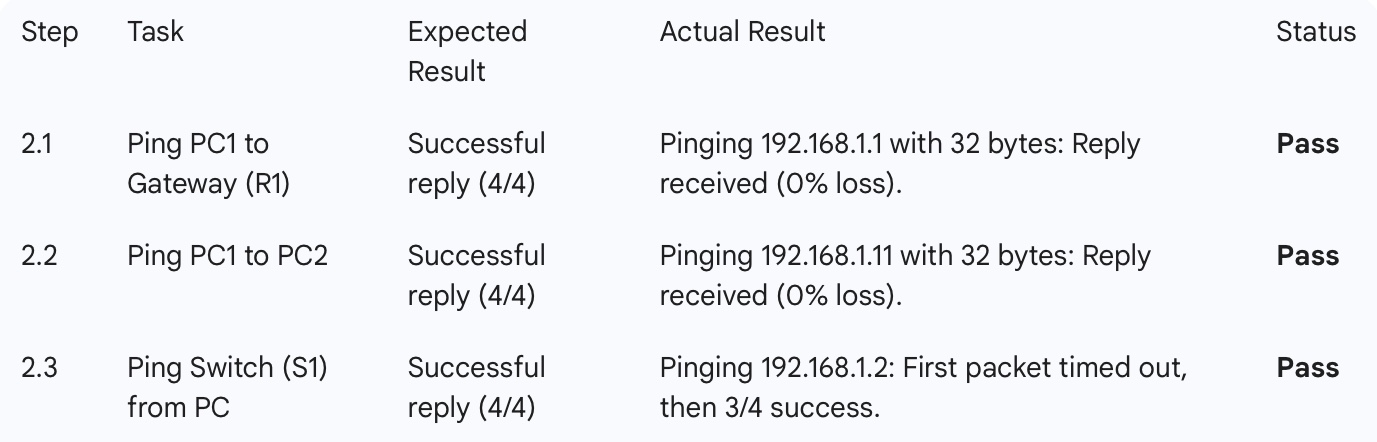

---
#👤 Part 3: การวิเคราะห์โครงสร้าง Protocol (อ้น)

**หน้าที่: เจาะลึกข้อมูลในระดับ Packet ผ่าน Simulation Mode**

**ขั้นตอนการดำเนินงาน**

1. **Event Filter**

 * ปรับโหมดเป็น Simulation และเลือกกรองเฉพาะโปรโตคอล **ICMP** และ **ARP**

2. **PDU Information Analysis**

 * คลิกที่ซองจดหมายเพื่อดู **Inbound/Outbound PDU Details**

 * วิเคราะห์ **Layer 2 (Ethernet II)**: ตรวจสอบ Source/Destination MAC Address

 * วิเคราะห์ **Layer 3 (IP)**: ตรวจสอบ TTL (Time to Live) และ Source/Destination IP

```
[รันบน R1 หรือ S1]

show ip interface brief    # ตรวจสอบสถานะพอร์ต (Status: up, Protocol: up)
show interfaces            # ดูรายละเอียด MTU และ Encapsulation (ARPA)

```

3. **Flow Tracking**
 * ติดตามการเดินทางของข้อมูลจากต้นทางผ่าน Switch ไปยัง Router และปลายทาง

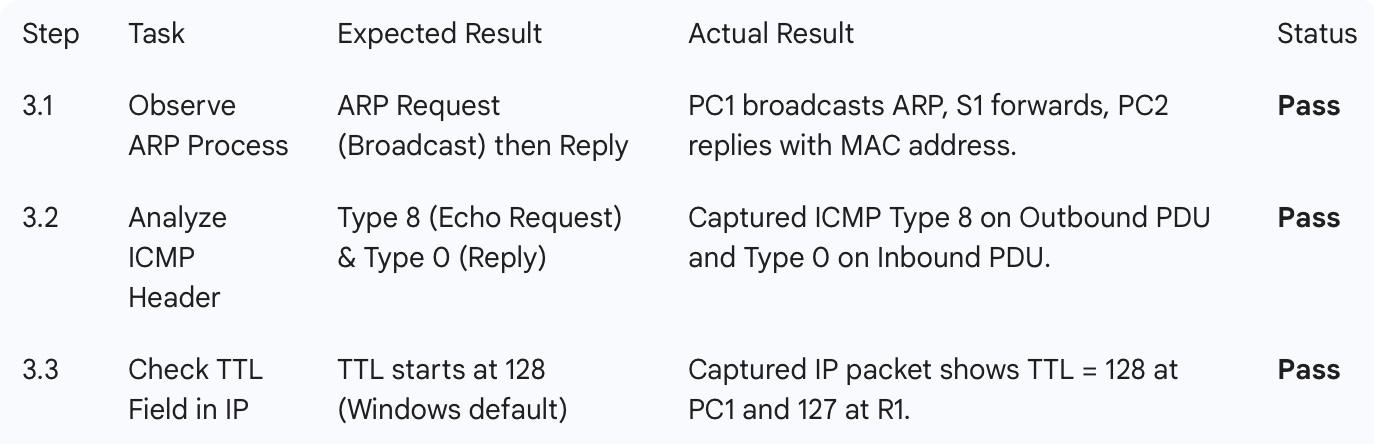

---
#👤 Part 4: การแก้ไขปัญหาและตาราง Address (เนย)

**หน้าที่: ตรวจสอบความถูกต้องของตารางความจำในอุปกรณ์ (ARP & MAC)**

**ขั้นตอนการดำเนินงาน**

1. **ARP Table Check**    

 * บน PC1 ใช้คำสั่ง `arp -a` เพื่อดูว่ามีการจับคู่ IP กับ MAC Address ของเพื่อนร่วมเครือข่ายถูกต้องหรือไม่

```
[ รันบน PC1 / PC2 (Command Prompt) ]

arp -a          # ตรวจสอบตาราง ARP (Mapping IP to MAC)

```

2. **MAC Address Table**

 * เข้าไปที่ Switch (S1) และใช้คำสั่ง `show mac address-table` เพื่อดูว่าพอร์ต Fa0/1 และ Fa0/2 เชื่อมต่อกับอุปกรณ์ใด

```
[ รันบน Switch S1 ]

show mac address-table   # ตรวจสอบว่า Switch เรียนรู้ MAC จากพอร์ตไหนบ้าง

```

3. **Issue Resolution**

 * หาก Ping ไม่ติด ให้ตรวจสอบ Firewall ของ PC หรือตรวจสอบว่าสถานะพอร์ตของ Router ถูก `no shutdown` แล้วหรือยัง

```
[ รันบน Router R1 ]

show arp        # ตรวจสอบตาราง ARP ในระดับ Router

```

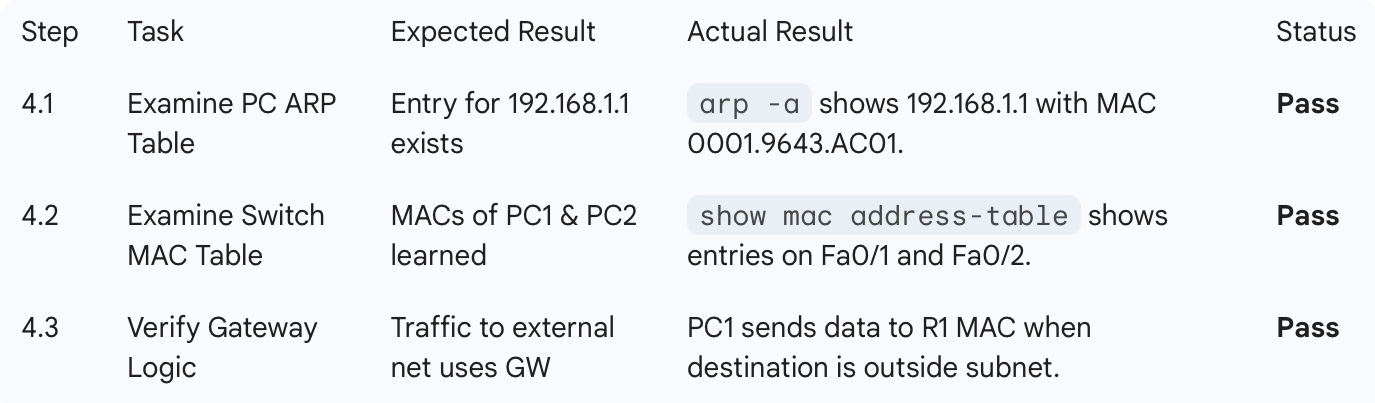

---
#👤 Part 5: สรุปผลและการตอบคำถามท้ายบท (บูบู้)

**หน้าที่: รวบรวมข้อมูลทั้งหมดและสรุปองค์ความรู้**

**ขั้นตอนการดำเนินงาน**

1. **Data Synthesis**

 * สรุปว่ากระบวนการ Encapsulation เกิดขึ้นอย่างไร (เช่น ข้อมูลจาก Layer 3 ถูกหุ้มด้วย Layer 2 Header ก่อนส่งออก)

2. **Q&A Session** ตอบคำถามจากไฟล์ Lab เช่น:

 * ทำไม Switch ถึงต้องการ IP? (เพื่อการจัดการระยะไกล/Remote Management)

 * TTL คืออะไร? (ค่าที่ป้องกันไม่ให้ Packet วนลูปในเครือข่ายตลอดไป)

3. **Final Review**
 * ตรวจสอบความเรียบร้อยของรายงานและไฟล์ `.pkt` ก่อนนำส่ง

```
[ รันบน R1 และ S1 ]

copy running-config startup-config   # หรือพิมพ์สั้นๆ ว่า 'write'

```



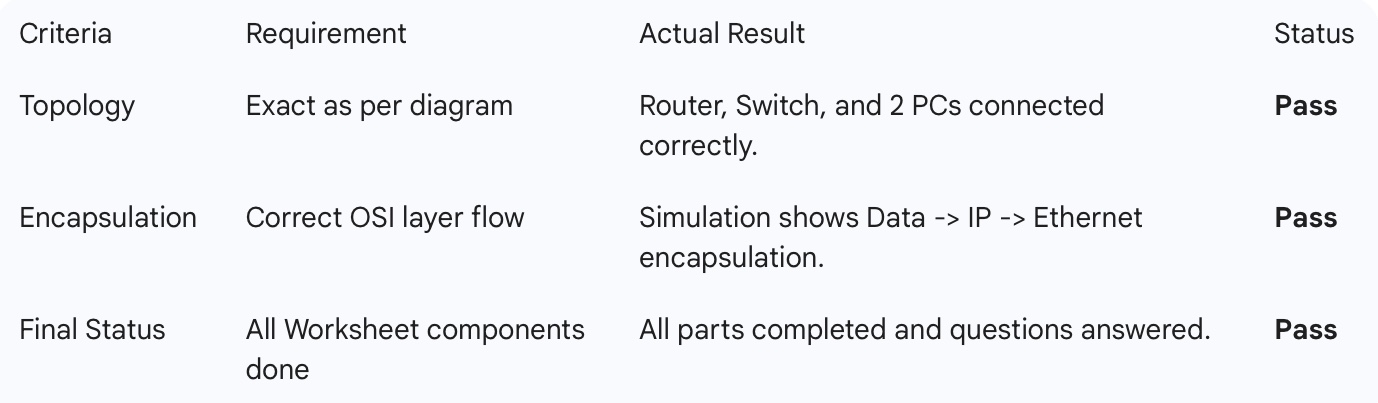

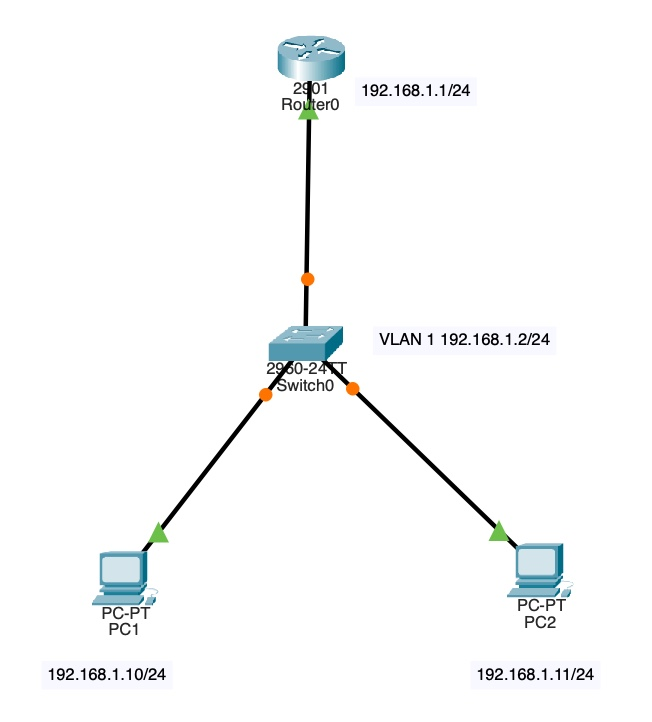

---
#📝 สรุปผลการดำเนินงาน (Lab Summary)
จากการปฏิบัติการจำลองเครือข่ายพื้นฐานผ่านโปรแกรม Cisco Packet Tracer สมาชิกในกลุ่มได้ร่วมกันตั้งค่าและตรวจสอบการทำงานของระบบ โดยมีผลสรุปดังนี้

1. **การเชื่อมต่อทางกายภาพและซอฟต์แวร์ (Physical & Software Connectivity)**

 * **การตั้งค่าอุปกรณ์**: อุปกรณ์ทั้งหมด (R1, S1, PC1, PC2) ถูกตั้งค่า IP Address ให้อยู่ในวง Network เดียวกันคือ `192.168.1.0/24 ได้สำเร็จ`

 * **สถานะการเชื่อมต่อ**: ผลการทดสอบด้วยคำสั่ง `ping` พบว่าอุปกรณ์ทุกตัวสามารถสื่อสารกันได้แบบต้นทางถึงปลายทาง (End-to-End) โดยมีอัตราการสูญเสียแพ็กเก็ตเป็น 0% (ยกเว้นแพ็กเก็ตแรกที่อาจ Time out จากกระบวนการ ARP)

2. **การวิเคราะห์โปรโตคอลและเลเยอร์ (Protocol & Layer Analysis)**

 * **Encapsulation**: จากการตรวจสอบใน Simulation Mode พบกระบวนการหุ้มห่อข้อมูลในแต่ละเลเยอร์อย่างชัดเจน โดยข้อมูลจาก Application Layer จะถูกหุ้มด้วย **IP Header (Layer 3)** และ **Ethernet Header (Layer 2)** ก่อนจะถูกส่งออกไปเป็น Bit (Layer 1)

 * **Protocol Roles**:
   * **ARP**: ทำหน้าที่สำคัญในการค้นหา MAC Address จาก IP Address ทำให้ Switch สามารถส่งเฟรมข้อมูลไปยังพอร์ตที่ถูกต้องได้

   * **ICMP**: ถูกใช้ในการทดสอบสถานะการเชื่อมต่อ (Echo Request/Reply)

   * **TTL (Time to Live)**: สังเกตเห็นว่าเมื่อแพ็กเก็ตวิ่งผ่าน Router ค่า TTL จะลดลง 1 เสมอ ซึ่งเป็นกลไกป้องกันการเกิด Loop ในเครือข่าย

3. **การจัดการ Address Tables**

 * **MAC Address Table**: บน Switch (S1) มีการเรียนรู้และบันทึกค่า MAC Address ของ PC1 และ PC2 ลงในตารางโดยอัตโนมัติเมื่อมีการรับส่งข้อมูล

 * **ARP Table**: บน PC1 และ PC2 มีการบันทึก IP และ MAC Address ของ Gateway และเครื่องคอมพิวเตอร์ข้างเคียง ทำให้การสื่อสารครั้งต่อๆ ไปรวดเร็วยิ่งขึ้น

4. **ปัญหาที่พบและการแก้ไข (Troubleshooting)**

 * **Default Gateway**: ในตอนแรก Switch ไม่สามารถ Ping ไปยังเครือข่ายภายนอกได้เนื่องจากยังไม่ได้ตั้งค่า `ip default-gateway` สมาชิกได้ทำการแก้ไขโดยเพิ่มคำสั่งใน Part 1

 * **Firewall**: บางช่วง PC ไม่ตอบสนองต่อการ Ping จึงได้ทำการตรวจสอบและอนุญาตโปรโตคอล ICMP ในระบบปฏิบัติการจำลอง

---
#🏁 บทสรุป (Final Conclusion)

การทดลองนี้ทำให้กลุ่มของพวกเราเข้าใจถึงความสำคัญของ OSI Model ในสถานการณ์จริง ว่าแต่ละเลเยอร์ทำงานสอดประสานกันอย่างไร รวมถึงเข้าใจบทบาทของ Router และ Switch ที่ทำงานต่างกันในระดับ Layer 2 และ Layer 3 ซึ่งเป็นพื้นฐานสำคัญในการออกแบบและจัดการระบบเครือข่ายที่ซับซ้อนขึ้นในอนาคต